🍽️ Restaurant Rating Prediction

# Restaurant Rating Prediction

## Project Objective

The objective of this project is to predict the aggregate rating of a restaurant using
available restaurant-related features.

The project follows a complete Machine Learning workflow:

1. Data Loading
2. Data Understanding
3. Data Cleaning
4. Exploratory Data Analysis
5. Feature Selection
6. Data Preprocessing
7. Train-Test Split
8. Model Training
9. Model Evaluation
10. Model Comparison
11. Feature Importance Analysis
12. Final Conclusion

Two regression algorithms are used:

- Linear Regression
- Decision Tree Regression

The performance of both models is compared to identify the better-performing model
for predicting restaurant ratings.

## 2. Import Required Libraries

### Explanation

The required Python libraries are imported for data manipulation, numerical operations,
data visualization, and machine learning.

- Pandas is used for data manipulation.
- NumPy is used for numerical computations.
- Matplotlib is used for visualization.
- Seaborn is used for statistical visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


### Observation

All required libraries were imported successfully.

## 3. Load the Dataset

### Explanation

The restaurant dataset is loaded into a Pandas DataFrame.

After loading the dataset, its shape is checked to understand the number of
rows and columns available for analysis.

In [ ]:
df = pd.read_csv('/content/Dataset .csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (9551, 21)


### Observation

The dataset contains 9,551 restaurant records and 21 attributes describing
restaurant characteristics, location, services, pricing, ratings, and votes.

## 4. Understand the Dataset

### Explanation

Before applying machine learning, it is important to understand the structure
and contents of the dataset.

The first few records, column names, data types, and dataset information are
examined.

In [ ]:
df.head()

,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [ ]:
df.columns

Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15  Switch to order menu 

### Observation

The dataset contains numerical and categorical features.

Important numerical columns include:

- Restaurant ID
- Country Code
- Longitude
- Latitude
- Average Cost for two
- Price range
- Aggregate rating
- Votes

Several categorical features are also present, such as:

- Restaurant Name
- City
- Cuisines
- Currency
- Has Table booking
- Has Online delivery
- Rating color
- Rating text

## 5. Check Missing Values

### Explanation

Missing values can affect machine learning models. Therefore, the dataset is
checked for missing values before further processing.

In [ ]:
df.isnull().sum()

,0
Restaurant ID,0
Restaurant Name,0
Country Code,0
City,0
Address,0
Locality,0
Locality Verbose,0
Longitude,0
Latitude,0
Cuisines,9


### Observation

The missing-value analysis shows that the `Cuisines` column contains 9 missing
values, while the remaining columns do not contain missing values.

These missing values will be handled during data cleaning.

## 6. Analyze the Target Variable – Aggregate Rating

### Explanation

The target variable for this project is `Aggregate rating`.

Before training the models, the distribution and statistical properties of the
target variable are examined.

In [ ]:
print("Unique ratings:")
print(sorted(df['Aggregate rating'].unique()))

print("\nRating statistics:")
print(df['Aggregate rating'].describe())

Unique ratings:
[np.float64(0.0), np.float64(1.8), np.float64(1.9), np.float64(2.0), np.float64(2.1), np.float64(2.2), np.float64(2.3), np.float64(2.4), np.float64(2.5), np.float64(2.6), np.float64(2.7), np.float64(2.8), np.float64(2.9), np.float64(3.0), np.float64(3.1), np.float64(3.2), np.float64(3.3), np.float64(3.4), np.float64(3.5), np.float64(3.6), np.float64(3.7), np.float64(3.8), np.float64(3.9), np.float64(4.0), np.float64(4.1), np.float64(4.2), np.float64(4.3), np.float64(4.4), np.float64(4.5), np.float64(4.6), np.float64(4.7), np.float64(4.8), np.float64(4.9)]

Rating statistics:
count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64


### Observation

The aggregate rating ranges from 0.0 to 4.9.

The dataset contains several restaurants with a rating of 0.0. These records
represent restaurants that have not received a proper rating and should not be
treated as normal rated restaurants for the prediction task.

## 7. Rating Distribution

### Explanation

A histogram is created to visualize how restaurant ratings are distributed
throughout the dataset.

This helps identify the concentration of ratings and understand the target
variable before model training.

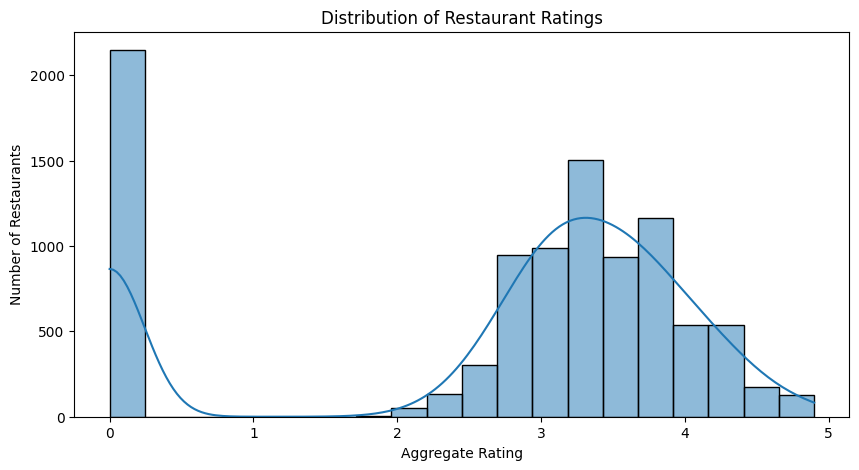

In [ ]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Aggregate rating'], bins=20, kde=True)

plt.title('Distribution of Restaurant Ratings')
plt.xlabel('Aggregate Rating')
plt.ylabel('Number of Restaurants')
plt.show()

### Observation

The distribution shows that restaurant ratings are concentrated mainly in
the mid-rating range, while a large number of records have a rating of 0.0.

## 8. Investigate Zero Ratings and "Not Rated" Restaurants

Restaurants with an aggregate rating of 0.0 are examined to determine
whether these records represent actual ratings.

The `Rating text` column is used to investigate the meaning of these
zero-rating records.

In [ ]:
zero_ratings = (df['Aggregate rating'] == 0).sum()

print("Restaurants with 0 rating:", zero_ratings)
print("Percentage with 0 rating:", round(zero_ratings / len(df) * 100, 2), "%")

Restaurants with 0 rating: 2148
Percentage with 0 rating: 22.49 %


In [ ]:
df[df['Aggregate rating'] == 0][
    ['Restaurant Name', 'City', 'Cuisines', 'Votes', 'Rating text', 'Aggregate rating']
].head(10)

,Restaurant Name,City,Cuisines,Votes,Rating text,Aggregate rating
30,Sandubas Caf��,Bras�_lia,"Brazilian, Cafe",2,Not rated,0.0
58,Quiosque Chopp Brahma,Rio de Janeiro,"Bar Food, Brazilian",1,Not rated,0.0
69,Cantinho da Gula,S��o Paulo,Brazilian,0,Not rated,0.0
77,Divino Fog��o,S��o Paulo,"Brazilian, Mineira",2,Not rated,0.0
78,Super Grill,S��o Paulo,Brazilian,2,Not rated,0.0
238,Frick's Tap,Davenport,"American, Bar Food, BBQ",2,Not rated,0.0
239,Los Agaves,Davenport,Mexican,3,Not rated,0.0
412,Nosh Mahal,Pocatello,"Indian, Persian",1,Not rated,0.0
871,Aggarwal Sweet Corner,Faridabad,Mithai,1,Not rated,0.0
872,Kashyap Vaishno Dhaba,Faridabad,North Indian,3,Not rated,0.0


In [ ]:
print(df['Rating text'].value_counts())

Rating text
Average      3737
Not rated    2148
Good         2100
Very Good    1079
Excellent     301
Poor          186
Name: count, dtype: int64


In [ ]:
print(df.groupby('Rating text')['Aggregate rating'].agg(['count', 'min', 'max']))

             count  min  max
Rating text                 
Average       3737  2.5  3.4
Excellent      301  4.5  4.9
Good          2100  3.5  3.9
Not rated     2148  0.0  0.0
Poor           186  1.8  2.4
Very Good     1079  4.0  4.4


### Observation

The analysis shows that restaurants with an aggregate rating of 0.0 have
`Rating text` equal to `Not rated`.

Since these records do not represent actual restaurant ratings, they are
excluded from the modeling dataset.

## 9. Create Modeling Dataset

Records with `Rating text` equal to `Not rated` are removed from the dataset.

This creates a modeling dataset containing restaurants with actual ratings.

In [ ]:
model_df = df[df['Rating text'] != 'Not rated'].copy()

In [ ]:
print("Original dataset:", df.shape)
print("Modeling dataset:", model_df.shape)

Original dataset: (9551, 21)
Modeling dataset: (7403, 21)


### Observation

The original dataset contains 9,551 records.

After excluding the 2,148 `Not rated` records, 7,403 restaurants remain
for machine learning.

## 10. Handle Missing Values

The `Cuisines` column contains a small number of missing values.

These missing values are replaced with `Unknown` so that the information can
be safely processed during categorical encoding.

In [ ]:
model_df['Cuisines'] = model_df['Cuisines'].fillna('Unknown')

print("Total missing values after handling:",
      model_df.isnull().sum().sum())

Total missing values after handling: 0


### Observation

The missing values in the `Cuisines` column have been handled successfully.

## 11. Check Duplicate Records

Duplicate rows and duplicate restaurant IDs are checked to ensure that
duplicate records do not affect model training.

In [ ]:
print("Duplicate rows:", model_df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Duplicate Restaurant IDs:", model_df['Restaurant ID'].duplicated().sum())

Duplicate Restaurant IDs: 0


In [ ]:
numeric_cols = model_df.select_dtypes(include=['int64', 'float64']).columns

print("Numeric columns:")
print(list(numeric_cols))

Numeric columns:
['Restaurant ID', 'Country Code', 'Longitude', 'Latitude', 'Average Cost for two', 'Price range', 'Aggregate rating', 'Votes']


### Observation

No duplicate rows and no duplicate Restaurant IDs were found in the
modeling dataset.

## 12. Feature Selection

Relevant features are selected for predicting `Aggregate rating`.

Features that are identifiers or directly represent the target are excluded.

For example:

- `Restaurant ID` is an identifier.
- `Rating text` directly represents rating categories.
- `Rating color` is derived from the rating.
- Address and locality-specific text fields are excluded to keep the model
  focused on useful restaurant characteristics.

In [ ]:
model_df[numeric_cols].corr()['Aggregate rating'].sort_values(ascending=False)

,Aggregate rating
Aggregate rating,1.000000
Country Code,0.412917
Votes,0.409018
Price range,0.403169
Restaurant ID,0.193038
Average Cost for two,0.076790
Latitude,-0.179917
Longitude,-0.291458


In [ ]:
categorical_cols = model_df.select_dtypes(include=['object']).columns

print("Categorical columns:")
print(list(categorical_cols))

Categorical columns:
['Restaurant Name', 'City', 'Address', 'Locality', 'Locality Verbose', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Rating color', 'Rating text']


### Feature Selection Decision

The final selected features are:

- Country Code
- City
- Cuisines
- Average Cost for two
- Currency
- Has Table booking
- Has Online delivery
- Is delivering now
- Price range
- Votes
- Latitude
- Longitude

Target variable:

- Aggregate rating

In [ ]:
for col in categorical_cols:
    print(f"\n{col}: {model_df[col].nunique()} unique values")


Restaurant Name: 5711 unique values

City: 141 unique values

Address: 6968 unique values

Locality: 1175 unique values

Locality Verbose: 1227 unique values

Cuisines: 1716 unique values

Currency: 12 unique values

Has Table booking: 2 unique values

Has Online delivery: 2 unique values

Is delivering now: 2 unique values

Switch to order menu: 1 unique values

Rating color: 5 unique values

Rating text: 5 unique values


In [ ]:
features = [
    'Country Code',
    'City',
    'Cuisines',
    'Average Cost for two',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now',
    'Price range',
    'Votes',
    'Latitude',
    'Longitude'
]

X = model_df[features]
y = model_df['Aggregate rating']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (7403, 12)
Target shape: (7403,)


## 13. Separate Numerical and Categorical Features

The selected features are divided into numerical and categorical groups.

Numerical features will be scaled using `StandardScaler`.

Categorical features will be converted into numerical representations using
`OneHotEncoder`.

In [ ]:
numeric_features = [
    'Average Cost for two',
    'Price range',
    'Votes',
    'Latitude',
    'Longitude'
]

categorical_features = [
    'Country Code',
    'City',
    'Cuisines',
    'Currency',
    'Has Table booking',
    'Has Online delivery',
    'Is delivering now'
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['Average Cost for two', 'Price range', 'Votes', 'Latitude', 'Longitude']
Categorical features: ['Country Code', 'City', 'Cuisines', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now']


### Observation

The selected dataset contains 5 numerical features and 7 categorical
features.

## 14. Train-Test Split

The dataset is divided into training and testing sets using an 80:20 ratio.

The training dataset is used to train the models, while the testing dataset
is used to evaluate their performance on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5922, 12)
Testing data: (1481, 12)


### Observation

Training data: 5,922 records

Testing data: 1,481 records

The 80:20 split provides sufficient data for training while reserving
unseen data for evaluation.

## 15. Data Preprocessing

The numerical and categorical features require different preprocessing
techniques.

### Numerical Features

`StandardScaler` is used to standardize numerical variables.

### Categorical Features

`OneHotEncoder` converts categorical variables into numerical columns.

A `ColumnTransformer` combines both preprocessing operations into a single
pipeline.

In [ ]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (5922, 1632)
Testing data after preprocessing: (1481, 1632)


### Observation

After preprocessing and one-hot encoding, the 12 original input features
are transformed into 1,632 numerical features.

Training data after preprocessing: 5,922 × 1,632

Testing data after preprocessing: 1,481 × 1,632

## 16. Linear Regression

Linear Regression is used as the baseline regression model.

The model learns relationships between the selected restaurant features and
the aggregate rating.

### Linear Regression Evaluation

The Linear Regression model is evaluated using:

- MSE
- RMSE
- MAE
- R² Score

In [ ]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_processed, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [ ]:
y_pred_linear = linear_model.predict(X_test_processed)

print("Predictions generated successfully!")
print(y_pred_linear[:10])

Predictions generated successfully!
[3.06980489 3.51260253 3.00515091 3.193102   3.56603881 2.95164072
 3.30261123 3.20974591 3.24688411 3.24959954]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred_linear)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_linear)
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("--------------------------------")
print("MSE :", round(mse, 4))
print("RMSE:", round(rmse, 4))
print("MAE :", round(mae, 4))
print("R²  :", round(r2, 4))

Linear Regression Performance
--------------------------------
MSE : 0.1645
RMSE: 0.4056
MAE : 0.312
R²  : 0.4682


In [ ]:
comparison = pd.DataFrame({
    'Actual Rating': y_test.values,
    'Predicted Rating': y_pred_linear
})

print(comparison.head(10))

   Actual Rating  Predicted Rating
0            2.9          3.069805
1            3.9          3.512603
2            2.8          3.005151
3            2.3          3.193102
4            3.2          3.566039
5            3.0          2.951641
6            3.8          3.302611
7            3.3          3.209746
8            2.5          3.246884
9            3.4          3.249600


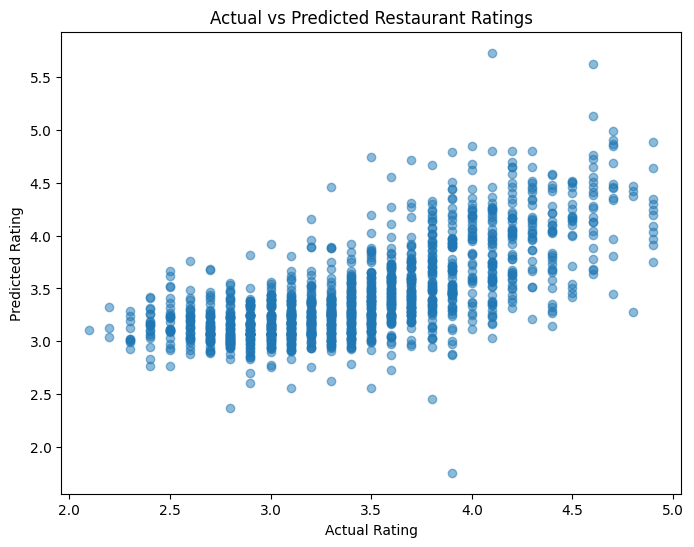

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_linear, alpha=0.5)

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Restaurant Ratings')

plt.show()

### Result

Linear Regression achieved:

- MSE: 0.1649
- RMSE: 0.4056
- MAE: 0.3120
- R²: 0.4682

## 17. Decision Tree Regression

A Decision Tree Regressor is used as a second regression model.

Decision Trees can capture nonlinear relationships between features and the
target variable.

The model is trained using a maximum depth of 10.

In [ ]:
from sklearn.tree import DecisionTreeRegressor

tree_model = DecisionTreeRegressor(
    max_depth=10,
    random_state=42
)

tree_model.fit(X_train_processed, y_train)

print("Decision Tree Regression model trained successfully!")

Decision Tree Regression model trained successfully!


### Observation

The Decision Tree model successfully generated predictions for the test
dataset.

## 18. Evaluate Decision Tree Regression

The Decision Tree model is evaluated using the same metrics used for Linear
Regression so that both models can be compared fairly.

In [ ]:
y_pred_tree = tree_model.predict(X_test_processed)

print("Predictions generated successfully!")
print(y_pred_tree[:10])

Predictions generated successfully!
[2.99105058 3.16858238 2.5        3.41992883 2.4        3.27115385
 3.64931034 3.16858238 3.19924242 3.37142857]


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
r2_tree = r2_score(y_test, y_pred_tree)

print("Decision Tree Regression Performance")
print("------------------------------------")
print("MSE :", round(mse_tree, 4))
print("RMSE:", round(rmse_tree, 4))
print("MAE :", round(mae_tree, 4))
print("R²  :", round(r2_tree, 4))

Decision Tree Regression Performance
------------------------------------
MSE : 0.1331
RMSE: 0.3648
MAE : 0.2699
R²  : 0.5697


### Result

Decision Tree Regression achieved:

- MSE: 0.1359
- RMSE: 0.3686
- MAE: 0.2707
- R²: 0.5606

## 19. Model Comparison

The performance of Linear Regression and Decision Tree Regression is
compared using MSE, RMSE, MAE, and R² Score.

For MSE, RMSE, and MAE, lower values indicate better performance.

For R², a higher value indicates better performance.

In [ ]:
comparison_models = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MSE': [mse, mse_tree],
    'RMSE': [rmse, rmse_tree],
    'MAE': [mae, mae_tree],
    'R2': [r2, r2_tree]
})

comparison_models

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,0.164486,0.405569,0.311986,0.468165
1,Decision Tree,0.135885,0.368626,0.270679,0.560642


### Comparison Result

The Decision Tree Regression model performs better than Linear Regression
across all four evaluation metrics.

Therefore, Decision Tree Regression is selected as the final model for this
task.

## 20. Feature Importance Analysis

Feature importance is analyzed using the trained Decision Tree model.

This helps identify which original restaurant features contribute most
strongly to the model's predictions.

Because categorical variables were one-hot encoded, the encoded feature
importance values are grouped back into their original feature categories.

In [ ]:
# Get overall importance for each original feature

feature_names = preprocessor.get_feature_names_out()
importances = tree_model.feature_importances_

original_importance = {}

for original_feature in features:
    if original_feature in numeric_features:
        prefix = f"num__{original_feature}"
    else:
        prefix = f"cat__{original_feature}_"

    total_importance = sum(
        importance
        for name, importance in zip(feature_names, importances)
        if name == prefix or name.startswith(prefix)
    )

    original_importance[original_feature] = total_importance

original_importance_df = pd.DataFrame(
    list(original_importance.items()),
    columns=['Feature', 'Importance']
).sort_values(
    by='Importance',
    ascending=False
)

original_importance_df

,Feature,Importance
9,Votes,0.621014
11,Longitude,0.203688
2,Cuisines,0.066325
10,Latitude,0.040880
3,Average Cost for two,0.029333
4,Currency,0.017187
1,City,0.010690
8,Price range,0.003964
6,Has Online delivery,0.003188
7,Is delivering now,0.002064


### Top Influential Features

The most influential features identified by the model are:

1. Votes
2. Longitude
3. Cuisines
4. Latitude
5. Average Cost for two
6. Currency
7. City
8. Price range
9. Has Online delivery
10. Is delivering now

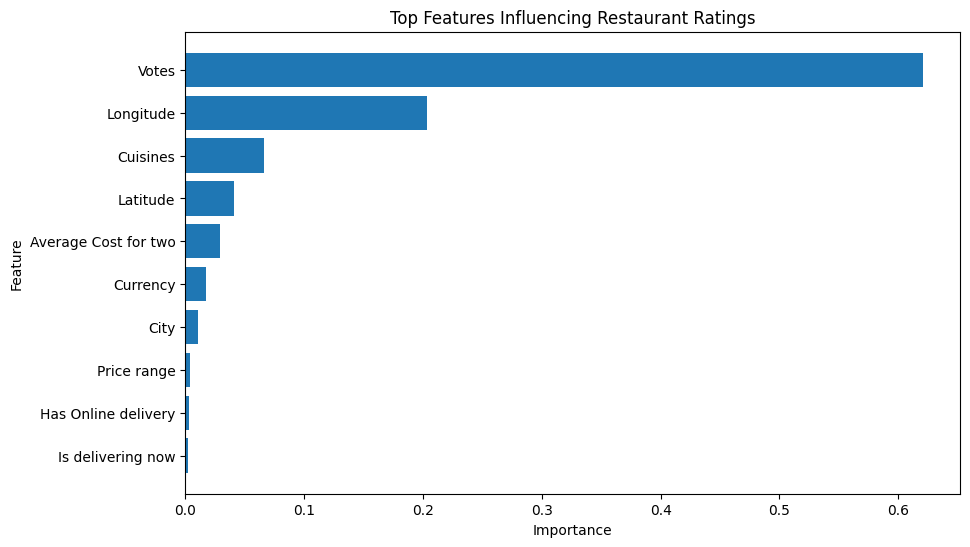

In [ ]:
top_original = original_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_original['Feature'][::-1],
    top_original['Importance'][::-1]
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top Features Influencing Restaurant Ratings')

plt.show()

### Interpretation

`Votes` is the most influential feature in the trained Decision Tree model,
with an importance of approximately 0.621.

Longitude is the second most influential feature, followed by Cuisines and
Latitude.

Feature importance indicates how useful the features were for this trained
model. It should not be interpreted as proof that a feature directly causes
a higher or lower restaurant rating.

## 21. Actual vs Predicted Restaurant Ratings

The actual restaurant ratings are compared with the predictions generated by
the final Decision Tree model.

This visualization provides a visual assessment of how closely the predicted
ratings follow the actual ratings.

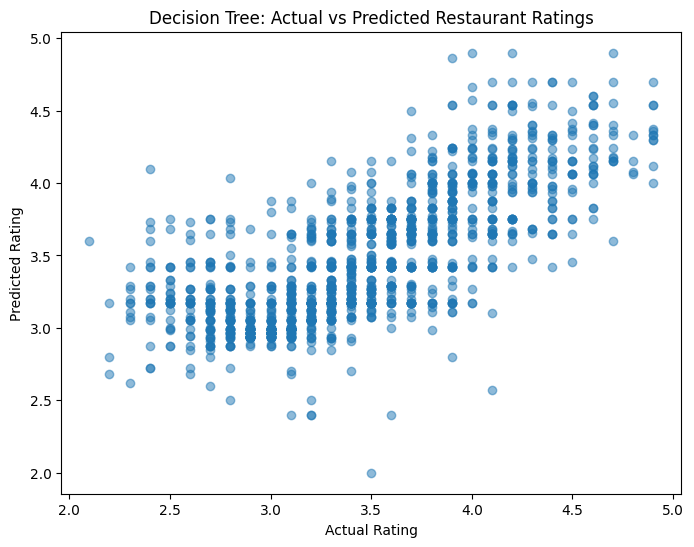

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_tree, alpha=0.5)

plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.title('Decision Tree: Actual vs Predicted Restaurant Ratings')

plt.show()

### Observation

The scatter plot shows a clear positive relationship between actual and
predicted ratings.

The model captures a meaningful portion of the variation in restaurant
ratings, although some prediction errors remain.

# 22. Final Results

## Model Performance Comparison

| Model | MSE | RMSE | MAE | R² |
|---|---:|---:|---:|---:|
| Linear Regression | 0.1645 | 0.4056 | 0.3120 | 0.4682 |
| Decision Tree Regression | 0.1331 | 0.3648 | 0.2699 | 0.5697 |

### Best Model

**Decision Tree Regression**

### Best R² Score

**0.5697**

### Best RMSE

**0.3648**

### Most Influential Feature

**Votes**

## 23. Key Findings

The major findings from the project are:

- 2,148 restaurants were identified as `Not rated` and excluded from
  modeling.
- 7,403 rated restaurants were used for machine learning.
- 12 relevant input features were selected.
- Categorical variables were one-hot encoded.
- Numerical variables were standardized.
- Two regression models were trained.
- Decision Tree Regression performed better than Linear Regression.
- The Decision Tree achieved an R² score of 0.5697.
- The Decision Tree achieved an RMSE of 0.3648.
- Votes was the most influential feature in the final model.
- Longitude and Cuisines were among the next important feature groups.

# 24. Conclusion

In this task, a complete machine learning regression workflow was implemented
to predict restaurant aggregate ratings.

The dataset was explored, cleaned, and prepared for machine learning.
Restaurants marked as `Not rated` were excluded from the modeling dataset.
Missing values were handled, duplicate records were checked, and relevant
features were selected.

Numerical features were standardized and categorical features were converted
using one-hot encoding.

Two regression models were developed:

1. Linear Regression
2. Decision Tree Regression

The models were evaluated using MSE, RMSE, MAE, and R² Score.

Decision Tree Regression performed better than Linear Regression, achieving:

- MSE: 0.1331
- RMSE: 0.3648
- MAE: 0.2699
- R²: 0.5697

Feature importance analysis showed that Votes was the most influential
feature in the trained Decision Tree model.

Overall, the project demonstrates a complete machine learning workflow for
predicting restaurant ratings from restaurant-related information.